## Comparing the FS and RS AdEx models using Brian2

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

This notebook presents a comparison between three different models: Fast Spiking (FS) and Regular Spiking (RS) *AdEx* models published in [Depannemaecker et al., 2025](https://link.springer.com/article/10.1007/s10827-025-00893-7). 

The classical **AdEx** describes the evolution of the membrane potential $V(t)$ of a single compartment of a neuron membrane. It consists of a system of *two differential equations*:
\begin{align}
    \left\{
    \begin{array}{l}
        C \dfrac{dV}{dt} = -g_{L} (V - E_L) + g_L \Delta_T \exp \left( \dfrac{V - V_\textit{th}}{\Delta_T} \right) - w + I \\
        \tau_w \dfrac{dw}{dt} = a \left( V - E_L \right) - w
    \end{array}
    \right.
\end{align}
When the potential goes beyond ${V}_\textit{th}$, the exponential term generates an upswing of the membrane potential that mimics the exponential activation of $\textrm{\textit{Na}}^+$ channels in a Hodgkin–Huxley-type neuron model, leading to the initiation of an action potential. At a spike detection threshold (e.g. 0 mV), a series of reset conditions is triggered:
\begin{align}
    \left\{
    \begin{array}{l}
        V \rightarrow V_\textit{reset} \\
        w \rightarrow w + b
    \end{array}
    \right.
\end{align}

In this notebook neurons are (mainly) driven by **synaptic activation**. The input current $I$ is then defined as the sum of synaptic currents:
\begin{equation}
I = I_{syn} = g_E(E_e-V) + g_I(E_i-V)
\end{equation}
where $g_E$ and $g_I$ are the excitatory and inhibitory conductances, resepctively, and $E_e$ and $E_i$ are the reversal potential of the excitatory and inhibitory synapses, respectively.

The conductances are described by:
\begin{align}
    \left\{
    \begin{array}{l}
    g_E = Q_E \sum_{n_E} \delta(t-t_{spike}(n_E)) \exp \left(- \dfrac{t-t_{spike}(n_E)}{\tau_E} \right) \\
    g_I = Q_I \sum_{n_I} \delta(t-t_{spike}(n_I)) \exp \left(- \dfrac{t-t_{spike}(n_I)}{\tau_I} \right)
    \end{array}
    \right.
\end{align}
    
where $Q_E$ and $Q_I$ are the excitatory and inhibitory quantal conductances, respectively; $n_E$ and $n_E$ are the number of incoming spikes from excitatory and inhibitory synapses, respectively; $t_{spike}(n_E)$ and $t_{spike}(n_I)$ are the time at which the incoming excitatory and inhibitory spikes arrive, respectively; and finally ${\tau_E}$ and ${\tau_I}$ are the decay timescale. 

In [1]:
#%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import os
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 

fig_name = 'Figure_2B'

In [3]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [4]:
from ntmf.neurons import setting_simulation_Brian, voltage_clamp_synapse, AdEx_eqs
from ntmf.network import network_creation, extracting_pop_freq_and_std, extracting_single_pop_freq_and_std
from ntmf.config import get_input_config, get_network_config, get_params_model_SI, get_syn_info, adding_K_params, load_spike_data
from utils.Plots_helper import *

### Defining duration of the simulation

In [5]:
sim_duration = 5 * b2.second
dt = 0.1 * b2.ms  # time resolution
times = b2.arange(0, sim_duration, dt)

### Setting up the neuron models

In [6]:
data_folder = '../neuron_models/AdEx'
idx = 0 # in this case only one model per cell type is provided

In [7]:
# In case you don't want the current injected to be zero
# Comment the next three lines.
stim_t_start = 0
stim_t_end = int(sim_duration)
stim_amplitude = 0 * b2.nA

# Adding a "step of current" for testing
# Comment out next three lines if you like to inject a "step current".
#stim_t_start = 2   #seconds
#stim_t_end = 5     #seconds
#stim_amplitude = 0.35 * b2.nA

stim_unit = 1. * b2.ms
stim_time = sim_duration

# Setting up the step current injection protocol
tmp_size = 2 + stim_t_end  
tmp = np.zeros((tmp_size, 1)) * b2.amp
tmp[stim_t_start: stim_t_end + 1, 0] = stim_amplitude
curr_array = b2.TimedArray(tmp, dt=1. * stim_unit).values.flatten()  # to solve the issue with dimention of the current vector
current_timed_array = b2.TimedArray(curr_array * b2.amp, dt=stim_unit)

In [8]:
neuron_model = 'FS'
G_FS = setting_simulation_Brian(idx = idx,
                                neuron_model = neuron_model,
                                json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                curr_inj = current_timed_array)


neuron_model = 'RS'
G_RS = setting_simulation_Brian(idx = idx,
                                neuron_model = neuron_model,
                                json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                curr_inj = current_timed_array)

# We are also considering a version of RS without adaptation, such as b=0.
neuron_model = 'RS_no_adapt'
G_RS_na = setting_simulation_Brian(idx = idx,
                                    neuron_model = neuron_model,
                                    json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                    curr_inj = current_timed_array)

### Defining/Reading the external drive/input

In [9]:
input_config = get_input_config(json_file_name = '../config/input_config_Fig2B.json') 

In [10]:
input_config

{'metainfo': 'Input config file -- sim',
 'connections': {'N_external_exc': 8000,
  'N_external_inh': 2000,
  'conn_prob': 0.05},
 'rates': {'freq_exc_FS': 1,
  'freq_exc_RS': 2,
  'freq_inh_FS': 10,
  'freq_inh_RS': 30,
  'background_freq': 0.5},
 'units': {'freq_exc_FS': 'Hz',
  'freq_exc_RS': 'Hz',
  'freq_inh_FS': 'Hz',
  'freq_ing_RS': 'Hz',
  'background_freq': 'Hz'}}

In [11]:
b2.seed(1234) # fixing seed for reproducibility 

# number of external neurons - number of incoming spikes
N_external_exc = input_config['connections']['N_external_exc']
N_external_inh = input_config['connections']['N_external_inh']
conn_prob =  input_config['connections']['conn_prob']

rate_exc_background = input_config['rates']['background_freq'] * b2.Hz # firing rate of the external input
rate_exc_external_input_FS = input_config['rates']['freq_exc_FS'] * b2.Hz # firing rate of the external input
rate_exc_external_input_RS = input_config['rates']['freq_exc_RS'] * b2.Hz # firing rate of the external input
rate_exc_external_input_RS_na = input_config['rates']['freq_exc_RS'] * b2.Hz # firing rate of the external input

# Poissoninan background input activity
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 0 * b2.second
p_end = sim_duration
rate_array[(times >= p_start) & (times < p_end)] = rate_exc_background
# Create the TimedArray
rate_timed_array_all = b2.TimedArray(rate_array, dt=dt)


# Poissoninan input for FS neurons
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 1 * b2.second
p_end = 2 * b2.second
rate_array[(times >= p_start) & (times < p_end)] = rate_exc_external_input_FS
# Create the TimedArray
rate_timed_array_exc_FS = b2.TimedArray(rate_array, dt=dt)

# Poissoninan input for RS neurons
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 1 * b2.second
p_end = 2 * b2.second
rate_array[(times >= p_start) & (times < p_end)] = rate_exc_external_input_RS
rate_timed_array_exc_RS = b2.TimedArray(rate_array, dt=dt)

# Poissoninan input for RS neurons
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 1 * b2.second
p_end = 2 * b2.second
rate_array[(times >= p_start) & (times < p_end)] = rate_exc_external_input_RS_na
rate_timed_array_exc_RS_na = b2.TimedArray(rate_array, dt=dt)

P_ed_exc_all = b2.PoissonGroup(N_external_exc, rates='rate_timed_array_all(t)')
P_ed_exc_FS = b2.PoissonGroup(N_external_exc, rates='rate_timed_array_exc_FS(t)')
P_ed_exc_RS = b2.PoissonGroup(N_external_exc, rates='rate_timed_array_exc_RS(t)')
P_ed_exc_RS_na = b2.PoissonGroup(N_external_exc, rates='rate_timed_array_exc_RS_na(t)')

# differentiate the intervals if they are different
exc_intervals = [(p_start/b2.second, p_end/b2.second)]

### Inhibitory external drive ###
rate_inh_external_input_FS = input_config['rates']['freq_inh_FS'] * b2.Hz # firing rate of the external input
rate_inh_external_input_RS = input_config['rates']['freq_inh_RS'] * b2.Hz # firing rate of the external input
rate_inh_external_input_RS_na = input_config['rates']['freq_inh_RS'] * b2.Hz # firing rate of the external input

# Poissoninan input for FS neurons
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 3 * b2.second
p_end = 4 * b2.second
rate_array[(times >= p_start) & (times < p_end)] = rate_inh_external_input_FS
# Create the TimedArray
rate_timed_array_inh_FS = b2.TimedArray(rate_array, dt=dt)

# Poissoninan input for RS neurons
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 3 * b2.second
p_end = 4 * b2.second
rate_array[(times >= p_start) & (times < p_end)] = rate_inh_external_input_RS
rate_timed_array_inh_RS = b2.TimedArray(rate_array, dt=dt)

# Poissoninan input for RS neurons without adaptation
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 3 * b2.second
p_end = 4 * b2.second
rate_array[(times >= p_start) & (times < p_end)] = rate_inh_external_input_RS_na
rate_timed_array_inh_RS_na = b2.TimedArray(rate_array, dt=dt)

P_ed_inh_FS = b2.PoissonGroup(N_external_inh, rates='rate_timed_array_inh_FS(t)')
P_ed_inh_RS = b2.PoissonGroup(N_external_inh, rates='rate_timed_array_inh_RS(t)')
P_ed_inh_RS_na = b2.PoissonGroup(N_external_inh, rates='rate_timed_array_inh_RS_na(t)')

# differentiate the intervals if they are different
inh_intervals = [(p_start/b2.second, p_end/b2.second)]

In [12]:
exc_intervals, inh_intervals

([(1.0, 2.0)], [(3.0, 4.0)])

### Connecting the external input to the neuron models

In [13]:
# Quantal increment in synaptic conductances
Qe_FS, Qi_FS = get_syn_info(json_file_name = os.path.join(data_folder, 'FS.json'))
Qe_RS, Qi_RS = get_syn_info(json_file_name = os.path.join(data_folder, 'RS.json'))

# Background input (All the cell types receive the same and in our case Qe_FS=Qe_RS)
S_ed_background_FS = b2.Synapses(P_ed_exc_all, G_FS, on_pre='GsynE_post+=Qe_FS')
S_ed_background_FS.connect(p = conn_prob) # to have all-to-one connection remove the conn_prob
S_ed_background_RS = b2.Synapses(P_ed_exc_all, G_RS, on_pre='GsynE_post+=Qe_RS')
S_ed_background_RS.connect(p = conn_prob)
S_ed_background_RS_na = b2.Synapses(P_ed_exc_all, G_RS_na, on_pre='GsynE_post+=Qe_RS')
S_ed_background_RS_na.connect(p = conn_prob)

# Excitatory external input depending on the cell type
S_ed_exc_FS = b2.Synapses(P_ed_exc_FS, G_FS, on_pre='GsynE_post+=Qe_FS')
S_ed_exc_FS.connect(p = conn_prob)

S_ed_exc_RS = b2.Synapses(P_ed_exc_RS, G_RS, on_pre='GsynE_post+=Qe_RS')
S_ed_exc_RS.connect(p = conn_prob)

S_ed_exc_RS_na = b2.Synapses(P_ed_exc_RS_na, G_RS_na, on_pre='GsynE_post+=Qe_RS')
S_ed_exc_RS_na.connect(p = conn_prob)

# Inhibitory external input depending on the cell type
S_ed_inh_FS = b2.Synapses(P_ed_inh_FS, G_FS, on_pre='GsynI_post+=Qi_FS')
S_ed_inh_FS.connect(p = conn_prob)

S_ed_inh_RS = b2.Synapses(P_ed_inh_RS, G_RS, on_pre='GsynI_post+=Qi_RS')
S_ed_inh_RS.connect(p = conn_prob)

S_ed_inh_RS_na = b2.Synapses(P_ed_inh_RS_na, G_RS_na, on_pre='GsynI_post+=Qi_RS')
S_ed_inh_RS_na.connect(p = conn_prob)

### Defining the Monitors (variables to record)

In [14]:
mon_FS = b2.StateMonitor(G_FS, ['v', 'Is'], record=True)
mon_spike_FS = b2.SpikeMonitor(G_FS)

mon_RS = b2.StateMonitor(G_RS, ['v', 'Is'], record=True)
mon_spike_RS = b2.SpikeMonitor(G_RS)

mon_RS_na = b2.StateMonitor(G_RS_na, ['v', 'Is'], record=True)
mon_spike_RS_na = b2.SpikeMonitor(G_RS_na)

mon_Poisson_input_exc_FS = b2.SpikeMonitor(P_ed_exc_FS)
mon_Poisson_input_exc_RS = b2.SpikeMonitor(P_ed_exc_RS)
mon_Poisson_input_exc_RS_na = b2.SpikeMonitor(P_ed_exc_RS_na)
mon_Poisson_input_all = b2.SpikeMonitor(P_ed_exc_all)

mon_Poisson_input_inh_FS = b2.SpikeMonitor(P_ed_inh_FS)
mon_Poisson_input_inh_RS = b2.SpikeMonitor(P_ed_inh_RS)
mon_Poisson_input_inh_RS_na = b2.SpikeMonitor(P_ed_inh_RS_na)

In [15]:
# to explore what's in the Monitor, use:
# print(dir(mon_FS))
# or for more details
# help(mon_FS)

### Running the simulation of the three neuron models

In [16]:
%%time
b2.run(sim_duration, namespace={'current': current_timed_array,
                                'rate_timed_array_all': rate_timed_array_all,
                                'rate_timed_array_exc_FS': rate_timed_array_exc_FS,
                                'rate_timed_array_exc_RS': rate_timed_array_exc_RS,
                                'rate_timed_array_exc_RS_na': rate_timed_array_exc_RS_na,
                                'rate_timed_array_inh_FS': rate_timed_array_inh_FS,
                                'rate_timed_array_inh_RS': rate_timed_array_inh_RS,
                                'rate_timed_array_inh_RS_na': rate_timed_array_inh_RS_na,
                                'Qe_FS': Qe_FS,
                                'Qi_FS': Qi_FS,
                                'Qe_RS': Qe_RS,
                                'Qi_RS': Qi_RS})

CPU times: user 8.18 s, sys: 15.3 ms, total: 8.2 s
Wall time: 8.21 s


### Plotting the results

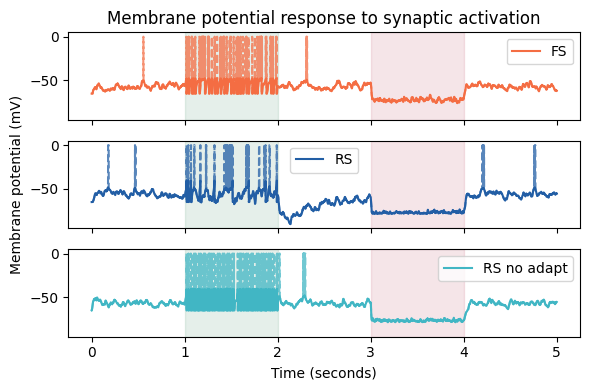

In [17]:
fig, ax = plt.subplots(3, 1, figsize=(6, 4), sharex=True)

v_RS_plot = get_pretty_voltage(mon_RS.v[0], -50)
v_RS_na_plot = get_pretty_voltage(mon_RS_na.v[0], -50)
v_FS_plot = get_pretty_voltage(mon_FS.v[0], -50)

ax[0].plot(mon_FS.t / b2.second, mon_FS.v[0] / b2.mV, color=color_palette['FS'], label = 'FS')
ax[0].plot(mon_FS.t / b2.second, v_FS_plot / b2.mV, '--' , color=color_palette['FS'], alpha=0.75)

ax[1].plot(mon_RS.t / b2.second, mon_RS.v[0] / b2.mV, color=color_palette['RS'], label = 'RS')
ax[1].plot(mon_RS.t / b2.second, v_RS_plot / b2.mV, '--' , color=color_palette['RS'], alpha=0.75)

ax[2].plot(mon_RS_na.t / b2.second, mon_RS_na.v[0] / b2.mV, color=color_palette['RS_no_adapt'], label = 'RS no adapt')
ax[2].plot(mon_RS_na.t / b2.second, v_RS_na_plot / b2.mV, '--' , color=color_palette['RS_no_adapt'], alpha=0.75)

ax[2].set_xlabel('Time (seconds)')
ax[1].set_ylabel('Membrane potential (mV)')
ax[0].set_title('Membrane potential response to synaptic activation')

ax[0].set_ylim(-95,5)
ax[1].set_ylim(-95,5)
ax[2].set_ylim(-95,5)

for a in ax:
    add_stim_spans(a, exc_intervals=exc_intervals, inh_intervals=inh_intervals)
    
plt.tight_layout()
ax[0].legend()
ax[1].legend()
ax[2].legend()

figs.append(fig)

In [18]:
save_figs(fig_path, fig_name, figs)